📥 Downloading 5 years of real multi-asset market data...


[*********************100%***********************]  12 of 12 completed


✅ Live market data retrieved successfully.
⚡ Running Quantum Annealing Simulator (48-qubit)...
🛡️ Applying Classical Strict-Constrained Polish...


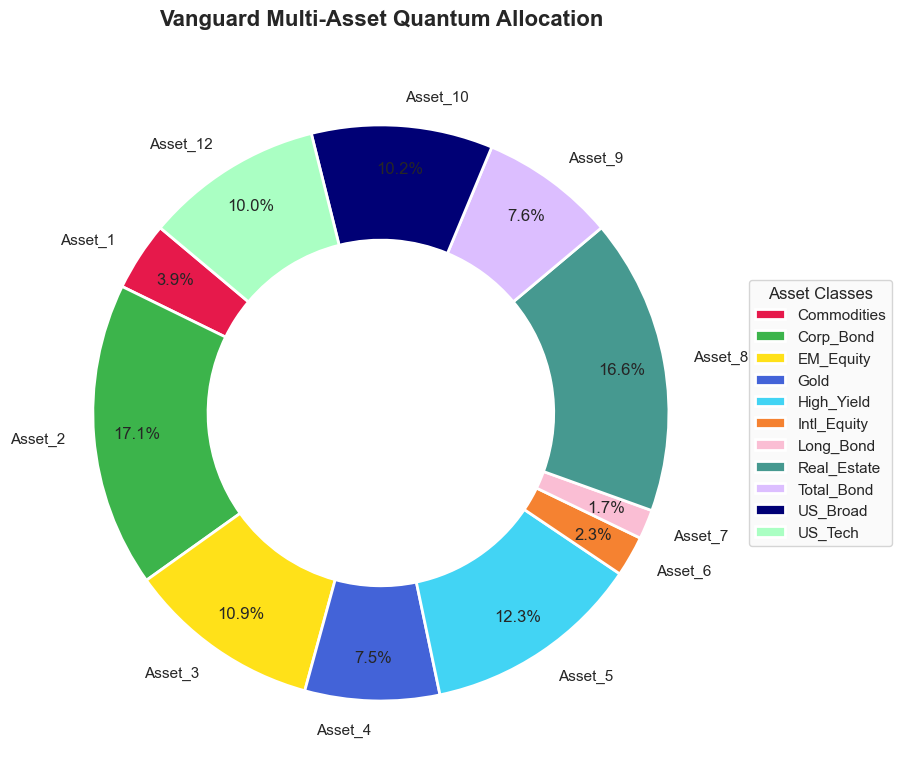

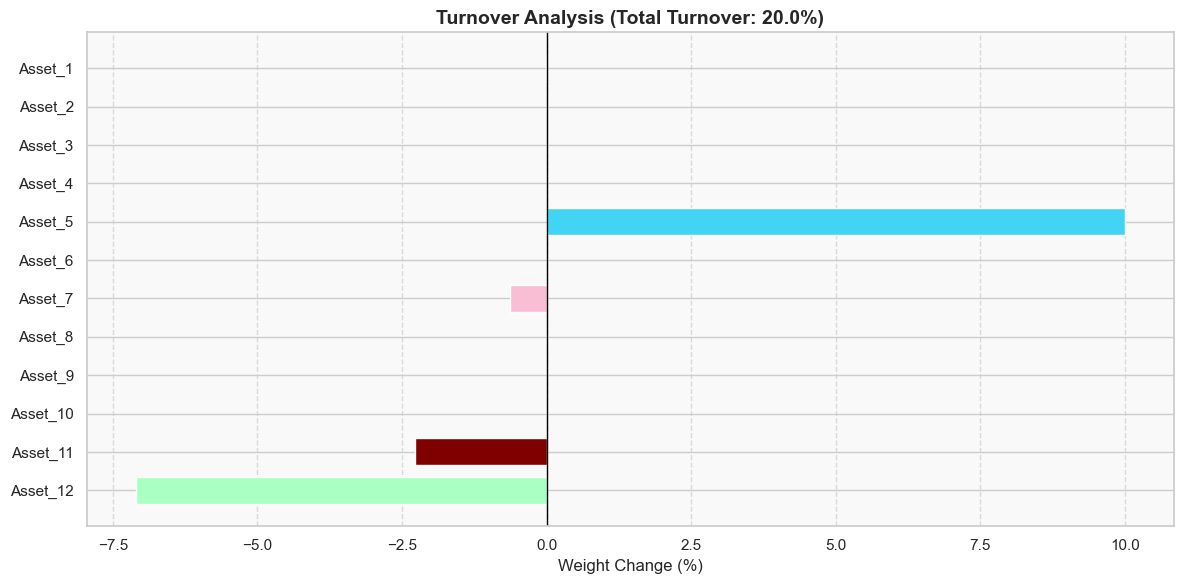


=========================================================
🤖 VANGUARD MULTI-ASSET HYBRID QUANTUM CO-PILOT
=========================================================

📊 PORTFOLIO SUMMARY (BALANCED PROFILE)
------------------------------------------------------
Expected Annual Return: 10.80%
Expected Volatility:    11.75%
Realized Turnover:      20.00% (Limit: 20%)

💼 MULTI-ASSET ALLOCATION BREAKDOWN
------------------------------------------------------
Asset_1  [███                                               ]   3.88%  (Class: US_Tech)
Asset_2  [█████████████████                                 ]  17.10%  (Class: US_Broad)
Asset_3  [██████████                                        ]  10.88%  (Class: Intl_Equity)
Asset_4  [███████                                           ]   7.55%  (Class: Long_Bond)
Asset_5  [████████████                                      ]  12.28%  (Class: Corp_Bond)
Asset_6  [██                                                ]   2.28%  (Class: Gold)
Asset_7  [█                                                 ]   1.65%  (Class: Commodities)
Asset_8  [████████████████                                  ]  16.62%  (Class: Real_Estate)
Asset_9  [███████                                           ]   7.59%  (Class: EM_Equity)
Asset_10 [██████████                                        ]  10.17%  (Class: Total_Bond)
Asset_11 [                                                  ]   0.00%  (Class: Short_Treasury)
Asset_12 [██████████                                        ]  10.00%  (Class: High_Yield)

🛡️ GUARDRAIL & COMPLIANCE CHECK (Zero Breaches)
------------------------------------------------------
[✅] Budget:         Total = 100.00% (Target: 100.00%)
[✅] Position Limit:  Max  = 17.10% (Limit: 25%)
[✅] Stress Test:     Equities = 39.45% (Limit: 50% - Downside Protection)
[✅] Sector:         Equities      = 39.45% (Limit: 40%)
[✅] Sector:         Fixed_Income  = 40.00% (Limit: 40%)
[✅] Sector:         Real_Assets   = 20.55% (Limit: 40%)
[✅] Sector:         Alternatives  = 0.00% (Limit: 40%)


In [3]:
import sys
import os
# Dynamically jump up one folder to find the 'src' directory
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visual theme for Vanguard (Clean, corporate)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['font.family'] = 'sans-serif'

# 1. Run the Pipeline (Silent mode)
from src.data_generator import get_multi_asset_data
from src.qubo_engine import build_qubo
from src.hybrid_solver import solve_hybrid
from src.copilot import generate_report

config = {
    "PROFILE_NAME": "Balanced",
    "LAMBDA_RISK": 2.0, "MAX_TURNOVER": 0.20, "EQUITY_STRESS_CAP": 0.50,
    "bits": 4, "max_weight": 0.25, "MAX_SECTOR": 0.40,
    "P_budget": 25.0, "P_sector": 25.0, "P_turnover": 15.0
}

# Run engine
data = get_multi_asset_data()
Q, n_qubits, step = build_qubo(data, config)
final_weights = solve_hybrid(Q, n_qubits, step, data, config)

# 2. Prepare Data for Charts
names = data['names']
asset_classes = data['asset_classes']
w0 = data['w0']

# Map classes to colors for consistent coloring
color_map = {
    'US_Tech': '#e6194B', 'US_Broad': '#3cb44b', 'Intl_Equity': '#ffe119', 
    'Long_Bond': '#4363d8', 'Corp_Bond': '#42d4f4', 'Total_Bond': '#000075',
    'Gold': '#f58231', 'Commodities': '#fabed4', 'Real_Estate': '#469990',
    'EM_Equity': '#dcbeff', 'Alt_Risk': '#9A6324', 'Short_Treasury': '#800000',
    'High_Yield': '#aaffc3', 'Cash': '#a9a9a9'
}
colors = [color_map.get(ac, '#333333') for ac in asset_classes]

# Filter out 0% weights for cleaner pie chart
non_zero_mask = final_weights > 0.001
filt_names = np.array(names)[non_zero_mask]
filt_weights = final_weights[non_zero_mask]
filt_colors = np.array(colors)[non_zero_mask]
filt_classes = np.array(asset_classes)[non_zero_mask]

# ==========================================
# VISUALIZATION 1: ALLOCATION PIE CHART
# ==========================================
fig1, ax1 = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax1.pie(
    filt_weights, labels=filt_names, autopct='%1.1f%%',
    colors=filt_colors, startangle=140, pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

# Add a circle in the middle for a donut chart (Modern UI look)
centre_circle = plt.Circle((0,0),0.60,fc='white')
ax1.add_artist(centre_circle)

# Add Legend for Asset Classes
legend_labels = [f"{cls}" for cls in np.unique(filt_classes)]
legend_colors = [color_map.get(cls, '#333333') for cls in np.unique(filt_classes)]
ax1.legend(legend_labels, title="Asset Classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

ax1.set_title('Vanguard Multi-Asset Quantum Allocation', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZATION 2: TURNOVER BAR CHART
# ==========================================
turnover_change = final_weights - w0

fig2, ax2 = plt.subplots(figsize=(12, 6))
y_pos = np.arange(len(names))
bars = ax2.barh(y_pos, turnover_change * 100, color=colors, edgecolor='white', height=0.7)

# Add zero line
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Format axes
ax2.set_yticks(y_pos)
ax2.set_yticklabels(names)
ax2.invert_yaxis() 
ax2.set_xlabel('Weight Change (%)', fontsize=12)
ax2.set_title(f'Turnover Analysis (Total Turnover: {np.sum(np.abs(turnover_change))*100:.1f}%)', fontsize=14, fontweight='bold')

# Add grid
ax2.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZATION 3: CO-PILOT TEXT REPORT
# ==========================================
from IPython.display import Markdown
report = generate_report(final_weights, data, config)
display(Markdown(report))

In [8]:
pwd

'/Users/vishaldhanure/Downloads/vanguard-quantum-portfolio'

In [5]:
ls -l notebooks/


total 16
-rw-r--r--  1 vishaldhanure  staff  7166 14 Jul 21:49 demo_prototype.ipynb
